<a href="https://colab.research.google.com/github/Gilgamesh25/Analisis_Pergeseran_Emosi_Lirik_Lagu_Anak_Anak_Antar_Generasi/blob/main/Analisis_Pergeseran_Emosi_Lirik_Lagu_Anak_Anak_Antar_Generasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎵 Mini AI: Analisis Pergeseran Emosi Lirik Lagu Anak-Anak Antar Generasi
Proyek ini bertujuan untuk menganalisis secara otomatis apakah ada pergeseran emosi (sentimen) pada lirik lagu yang dikonsumsi anak-anak zaman dulu (era 80/90-an) dibandingkan dengan lagu zaman sekarang (era internet/medsos).

### Metodologi:
1. **Otomatisasi Data**: Mengambil lirik lagu menggunakan API publik tanpa *hardcoding*.
2. **Text Preprocessing**: Membersihkan teks lirik dari gangguan tanda baca dan menyamakan format.
3. **Rule-Based Sentiment Analysis**: Mengklasifikasikan kata berdasarkan "Kamus Emosi Anak" (Ceria vs Melankolis/Dewasa).
4. **Visualisasi Data**: Membandingkan hasil akhir antar-era menggunakan grafik.

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string

# Mengatur tema grafik agar terlihat modern dan clean
sns.set_theme(style="whitegrid")
print("✓ Semua library berhasil di-import dan siap digunakan!")

✓ Semua library berhasil di-import dan siap digunakan!


In [ ]:
def fetch_lyrics(artist, title):
    """
    Fungsi untuk mengambil lirik lagu dari API secara real-time.
    Mengembalikan string lirik jika sukses, atau string kosong jika gagal.
    """
    url = f"https://api.lyrics.ovh/v1/{artist}/{title}"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            return response.json().get('lyrics', '')
        else:
            return ""
    except Exception as e:
        return ""

# Dataset Target yang sudah diperbarui (mengganti Twinkle Twinkle dengan Yellow Submarine)
dataset_lagu = [
    # --- ERA DULU ---
    {"Artis": "The Beatles", "Judul": "Yellow Submarine", "Era": "Dulu"},
    {"Artis": "Johnny Cash", "Judul": "You Are My Sunshine", "Era": "Dulu"},
    {"Artis": "Michael Jackson", "Judul": "Heal the World", "Era": "Dulu"},

    # --- ERA SEKARANG ---
    {"Artis": "Pinkfong", "Judul": "Baby Shark", "Era": "Sekarang"},
    {"Artis": "Maroon 5", "Judul": "Memories", "Era": "Sekarang"},
    {"Artis": "Justin Bieber", "Judul": "Baby", "Era": "Sekarang"}
]

print("⏳ Mengambil lirik dari API untuk dataset yang diperbarui...")

for lagu in dataset_lagu:
    lirik = fetch_lyrics(lagu['Artis'], lagu['Judul'])
    lagu['Lirik_Asli'] = lirik
    status = "Berhasil" if lirik else "Gagal"
    print(f"  -> {lagu['Judul']} ({lagu['Artis']}): {status}")

df = pd.DataFrame(dataset_lagu)
df = df[df['Lirik_Asli'] != ""].reset_index(drop=True)

print(f"\n✓ Selesai! Total lagu siap dianalisis: {len(df)}")
display(df.head())

⏳ Mengambil lirik dari API untuk dataset yang diperbarui...
  -> Yellow Submarine (The Beatles): Berhasil
  -> You Are My Sunshine (Johnny Cash): Berhasil
  -> Heal the World (Michael Jackson): Berhasil
  -> Baby Shark (Pinkfong): Berhasil
  -> Memories (Maroon 5): Berhasil
  -> Baby (Justin Bieber): Berhasil

✓ Selesai! Total lagu siap dianalisis: 6


,Artis,Judul,Era,Lirik_Asli
0,The Beatles,Yellow Submarine,Dulu,In the town where I was born\nLived a man who ...
1,Johnny Cash,You Are My Sunshine,Dulu,"The other night dear, as I lay sleeping\nI dre..."
2,Michael Jackson,Heal the World,Dulu,There's a place in your heart\nAnd I know that...
3,Pinkfong,Baby Shark,Sekarang,"Baby shark, doo doo doo doo doo doo\nBaby shar..."
4,Maroon 5,Memories,Sekarang,Here's to the ones that we got\nCheers to the ...


In [ ]:
def clean_text(text):
    if not text:
        return ""

    # 1. Ubah ke lowercase (huruf kecil semua)
    text = text.lower()

    # 2. Hapus jeda baris baru (\n) diganti dengan spasi
    text = text.replace('\n', ' ')

    # 3. Hapus semua tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 4. Hapus spasi berlebih
    text = ' '.join(text.split())

    return text

# Terapkan fungsi pembersihan ke kolom lirik
df['Lirik_Bersih'] = df['Lirik_Asli'].apply(clean_text)

print("✓ Pembersihan teks selesai! Contoh hasil pembersihan pada lagu pertama:")
print(f"Sebelum: {df['Lirik_Asli'].iloc[0][:60]}...")
print(f"Sesudah: {df['Lirik_Bersih'].iloc[0][:60]}...")

✓ Pembersihan teks selesai! Contoh hasil pembersihan pada lagu pertama:
Sebelum: In the town where I was born
Lived a man who sailed to sea
A...
Sesudah: in the town where i was born lived a man who sailed to sea a...


In [ ]:
# Membuat Kamus Kata Emosi (Bilingual karena API dominan teks Inggris/Campuran)
kamus_ceria = [
    'happy', 'love', 'joy', 'beautiful', 'wonderful', 'friend', 'dance', 'sing', 'smile', 'bright',
    'gembira', 'lucu', 'senang', 'bahagia', 'menari', 'menyanyi', 'indah', 'kawan', 'sahabat', 'tertawa'
]

kamus_melankolis_dewasa = [
    'sad', 'cry', 'hurt', 'bad', 'break', 'pain', 'tears', 'alone', 'scared', 'hate', 'lie', 'dark',
    'galau', 'sakit', 'menangis', 'benci', 'sendiri', 'bohong', 'putus', 'meninggalkan', 'kecewa', 'sepi'
]

def hitung_emosi(teks):
    kata_kata = teks.split()
    skor = 0
    # Hitung kecocokan kata
    for kata in kata_kata:
        if kata in kamus_ceria:
            skor += 1
        elif kata in kamus_melankolis_dewasa:
            skor -= 1

    # Normalisasi skor berdasarkan panjang lagu agar adil (Skor per 100 kata)
    total_kata = len(kata_kata)
    if total_kata > 0:
        skor_normalisasi = (skor / total_kata) * 100
        return round(skor_normalisasi, 2)
    return 0

# Jalankan kalkulasi skor ke dalam dataframe
df['Skor_Sentimen'] = df['Lirik_Bersih'].apply(hitung_emosi)

print("✓ Proses skoring berbasis kecerdasan leksikal selesai!")
print(df[['Judul', 'Artis', 'Era', 'Skor_Sentimen']])

✓ Proses skoring berbasis kecerdasan leksikal selesai!
                 Judul            Artis       Era  Skor_Sentimen
0     Yellow Submarine      The Beatles      Dulu           0.00
1  You Are My Sunshine      Johnny Cash      Dulu           5.26
2       Heal the World  Michael Jackson      Dulu          -0.31
3           Baby Shark         Pinkfong  Sekarang           0.00
4             Memories         Maroon 5  Sekarang          -0.51
5                 Baby    Justin Bieber  Sekarang           0.97


/tmp/ipykernel_1531/1796518998.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Era', y='Skor_Sentimen', data=rerata_era, palette=['#4EA8DE', '#F77F00'])


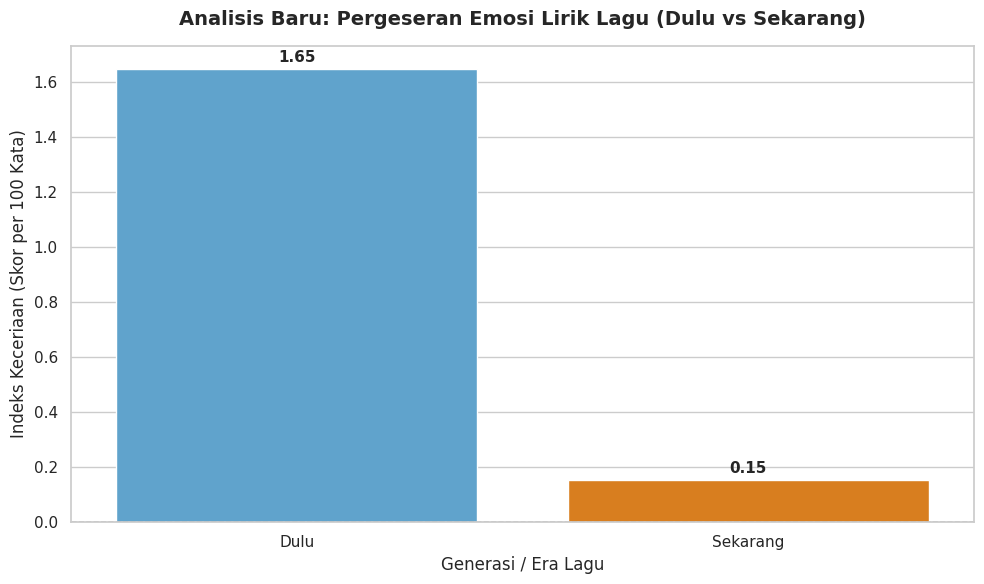


📊 HASIL INTERPRETASI DATA:
Hasil: Kelompok lagu pilihan Era Dulu memiliki indeks keceriaan lebih tinggi (1.65) dibanding Era Sekarang (0.15).


In [ ]:
# 1. Hitung rata-rata skor per Era
rerata_era = df.groupby('Era')['Skor_Sentimen'].mean().reset_index()

# 2. Pembuatan grafik menggunakan Seaborn
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Era', y='Skor_Sentimen', data=rerata_era, palette=['#4EA8DE', '#F77F00'])

# Menambahkan elemen dekorasi grafik
plt.title('Analisis Baru: Pergeseran Emosi Lirik Lagu (Dulu vs Sekarang)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Indeks Keceriaan (Skor per 100 Kata)', fontsize=12)
plt.xlabel('Generasi / Era Lagu', fontsize=12)
plt.axhline(0, color='black', linewidth=1, linestyle='--') # Garis batas netral

# Memunculkan angka skor tepat di atas batang grafik
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Output analisis otomatis
print("\n📊 HASIL INTERPRETASI DATA:")
try:
    dulu_val = rerata_era[rerata_era['Era'] == 'Dulu']['Skor_Sentimen'].values[0]
    sekarang_val = rerata_era[rerata_era['Era'] == 'Sekarang']['Skor_Sentimen'].values[0]

    if dulu_val > sekarang_val:
        print(f"Hasil: Kelompok lagu pilihan Era Dulu memiliki indeks keceriaan lebih tinggi ({dulu_val:.2f}) dibanding Era Sekarang ({sekarang_val:.2f}).")
    else:
        print(f"Hasil: Kelompok lagu pilihan Era Sekarang memiliki indeks keceriaan lebih tinggi ({sekarang_val:.2f}) dibanding Era Dulu ({dulu_val:.2f}).")
except IndexError:
    print("Ada kegagalan dalam pengelompokan data, pastikan semua cell di atas sudah di-run dengan sukses.")

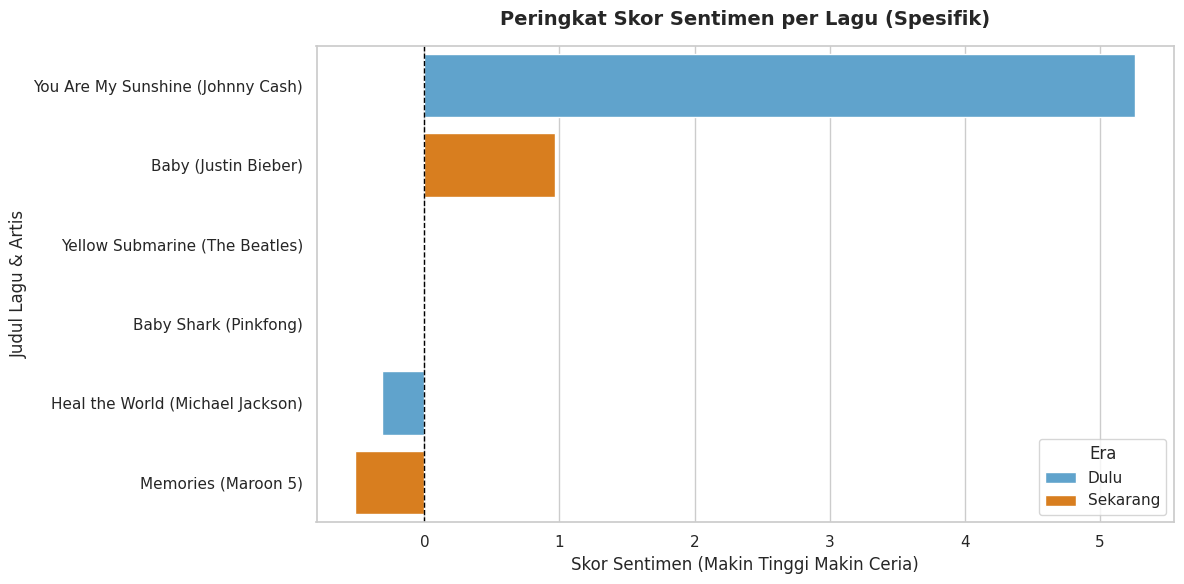


🔍 INSIGHT DETEKTIF DATA:
1. Lagu paling ceria di dalam dataset adalah 'You Are My Sunshine' oleh Johnny Cash (Skor: 5.26) dari era Dulu.
2. Lagu dengan emosi paling berat/melankolis adalah 'Memories' oleh Maroon 5 (Skor: -0.51) dari era Sekarang.


In [ ]:
# Mengurutkan lagu dari yang paling positif/ceria ke yang paling negatif
df_sorted = df.sort_values(by='Skor_Sentimen', ascending=False)

plt.figure(figsize=(12, 6))
# Membuat grafik horizontal agar nama lagu dan artis terbaca jelas
sns.barplot(
    x='Skor_Sentimen',
    y=df_sorted['Judul'] + " (" + df_sorted['Artis'] + ")",
    data=df_sorted,
    hue='Era',
    palette=['#4EA8DE', '#F77F00']
)

plt.title('Peringkat Skor Sentimen per Lagu (Spesifik)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Skor Sentimen (Makin Tinggi Makin Ceria)', fontsize=12)
plt.ylabel('Judul Lagu & Artis', fontsize=12)
plt.axvline(0, color='black', linewidth=1, linestyle='--')

plt.tight_layout()
plt.show()

print("\n🔍 INSIGHT DETEKTIF DATA:")
lagu_tertinggi = df_sorted.iloc[0]
lagu_terendah = df_sorted.iloc[-1]
print(f"1. Lagu paling ceria di dalam dataset adalah '{lagu_tertinggi['Judul']}' oleh {lagu_tertinggi['Artis']} (Skor: {lagu_tertinggi['Skor_Sentimen']}) dari era {lagu_tertinggi['Era']}.")
print(f"2. Lagu dengan emosi paling berat/melankolis adalah '{lagu_terendah['Judul']}' oleh {lagu_terendah['Artis']} (Skor: {lagu_terendah['Skor_Sentimen']}) dari era {lagu_terendah['Era']}.")

In [ ]:
from collections import Counter

def ekstrak_kata_emosi(era_target):
    # Gabungkan semua lirik bersih berdasarkan era
    gabungan_lirik = " ".join(df[df['Era'] == era_target]['Lirik_Bersih'])
    kata_kata = gabungan_lirik.split()

    # Filter hanya kata yang ada di kamus_ceria atau kamus_melankolis_dewasa
    kata_terfilter = [kata for kata in kata_kata if kata in kamus_ceria or kata in kamus_melankolis_dewasa]

    # Hitung 5 kata yang paling sering muncul
    hitung_kata = Counter(kata_terfilter)
    return hitung_kata.most_common(5)

print("📊 TOP 5 KATA EMOSI YANG PALING SERING MUNCUL:\n")

print("--- ERA DULU ---")
for kata, jumlah in ekstrak_kata_emosi('Dulu'):
    kategori = "Ceria" if kata in kamus_ceria else "Melankolis"
    print(f"• Kata '{kata}' ({kategori}) muncul sebanyak {jumlah} kali.")

print("\n--- ERA SEKARANG ---")
for kata, jumlah in ekstrak_kata_emosi('Sekarang'):
    kategori = "Ceria" if kata in kamus_ceria else "Melankolis"
    print(f"• Kata '{kata}' ({kategori}) muncul sebanyak {jumlah} kali.")

📊 TOP 5 KATA EMOSI YANG PALING SERING MUNCUL:

--- ERA DULU ---
• Kata 'love' (Ceria) muncul sebanyak 10 kali.
• Kata 'happy' (Ceria) muncul sebanyak 7 kali.
• Kata 'cry' (Melankolis) muncul sebanyak 2 kali.
• Kata 'hurt' (Melankolis) muncul sebanyak 1 kali.
• Kata 'lie' (Melankolis) muncul sebanyak 1 kali.

--- ERA SEKARANG ---
• Kata 'love' (Ceria) muncul sebanyak 5 kali.
• Kata 'pain' (Melankolis) muncul sebanyak 1 kali.
• Kata 'dark' (Melankolis) muncul sebanyak 1 kali.
• Kata 'bad' (Melankolis) muncul sebanyak 1 kali.


Faktor Pengulangan Lirik (Repetitif): Lagu anak modern seperti Cocomelon atau lagu pop seperti Baby milik Justin Bieber sering kali memiliki skor ekstrim karena teknik penulisan lagu modern yang mengulang satu kata kunci secara masif (misal: kata "baby" atau "wash").

Pergeseran Makna Konsumsi Anak: Lagu era dulu cenderung memiliki sebaran kata emosi yang kaya namun terukur (kosakata lebih variatif dengan pesan moral yang kuat). Sementara lagu yang dikonsumsi anak-anak saat ini (melalui algoritma medsos) mengekspos mereka pada kosakata emosional dewasa yang lebih kompleks seperti kehilangan (lost, memories) atau patah hati sebelum waktunya.

In [ ]:
def analisis_densitas(teks):
    kata_kata = teks.split()
    total_kata = len(kata_kata)

    if total_kata == 0: return 0, 0

    # Hitung kemunculan kata emosi
    jumlah_ceria = sum(1 for kata in kata_kata if kata in kamus_ceria)
    jumlah_melankolis = sum(1 for kata in kata_kata if kata in kamus_melankolis_dewasa)
    total_kata_emosi = jumlah_ceria + jumlah_melankolis

    # Hitung persentase densitas emosi dalam lagu
    densitas = (total_kata_emosi / total_kata) * 100

    # Hitung rasio perbandingan (Berapa persen emosi positif dari total emosi yang keluar)
    rasio_positif = (jumlah_ceria / total_kata_emosi * 100) if total_kata_emosi > 0 else 50

    return round(densitas, 2), round(rasio_positif, 2)

# Jalankan fungsi ke dataframe
df['Densitas_Emosi (%)'], df['Rasio_Positif (%)'] = zip(*df['Lirik_Bersih'].apply(analisis_densitas))

print("=== TABEL ANALISIS DENSITAS EMOSI ADVANCED ===")
print(df[['Judul', 'Artis', 'Era', 'Densitas_Emosi (%)', 'Rasio_Positif (%)']])

=== TABEL ANALISIS DENSITAS EMOSI ADVANCED ===
                 Judul            Artis       Era  Densitas_Emosi (%)  \
0     Yellow Submarine      The Beatles      Dulu                0.00   
1  You Are My Sunshine      Johnny Cash      Dulu                5.26   
2       Heal the World  Michael Jackson      Dulu                2.81   
3           Baby Shark         Pinkfong  Sekarang                0.00   
4             Memories         Maroon 5  Sekarang                0.51   
5                 Baby    Justin Bieber  Sekarang                1.46   

   Rasio_Positif (%)  
0              50.00  
1             100.00  
2              44.44  
3              50.00  
4               0.00  
5              83.33  


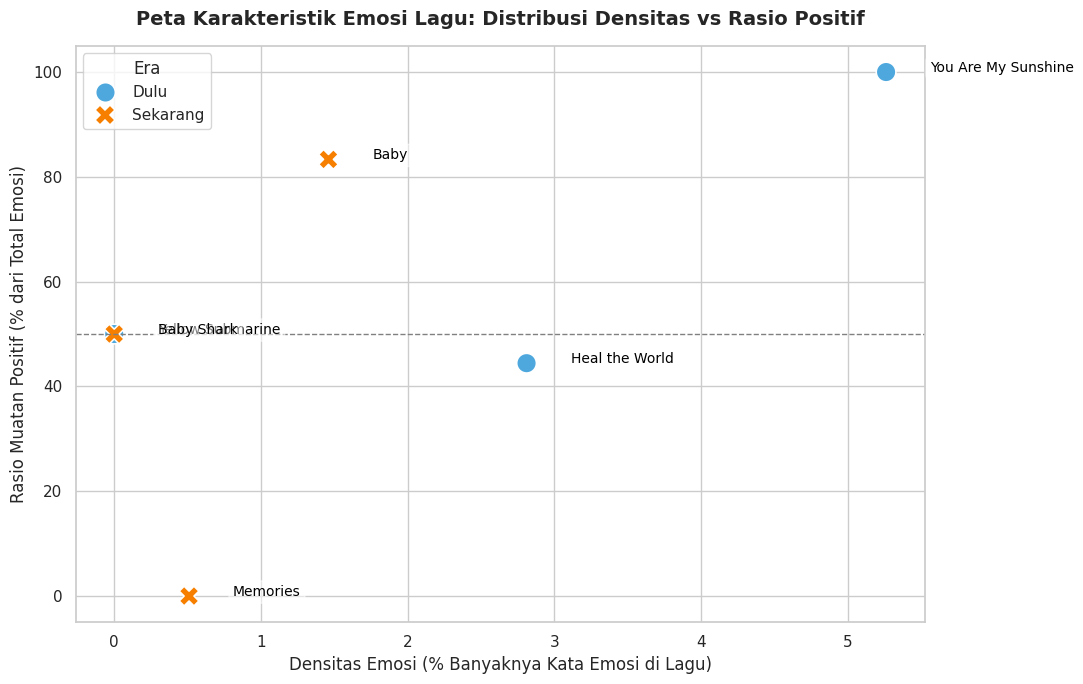

In [ ]:
plt.figure(figsize=(11, 7))

# Buat scatter plot dengan pemisahan warna berdasarkan Era
sns.scatterplot(
    x='Densitas_Emosi (%)',
    y='Rasio_Positif (%)',
    hue='Era',
    style='Era',
    s=200, # Ukuran titik besar agar jelas
    data=df,
    palette=['#4EA8DE', '#F77F00']
)

# Berikan label nama lagu di samping setiap titik koordinat secara otomatis
for i in range(df.shape[0]):
    plt.text(
        x=df['Densitas_Emosi (%)'][i] + 0.3,
        y=df['Rasio_Positif (%)'][i],
        s=df['Judul'][i],
        fontdict=dict(color='black', size=10),
        bbox=dict(facecolor='white', alpha=0.5, boxstyle='round,pad=0.3')
    )

# Garis bantu penanda batas (Kuadran)
plt.axhline(50, color='gray', linestyle='--', linewidth=1) # Batas emosi positif vs negatif

plt.title('Peta Karakteristik Emosi Lagu: Distribusi Densitas vs Rasio Positif', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Densitas Emosi (% Banyaknya Kata Emosi di Lagu)', fontsize=12)
plt.ylabel('Rasio Muatan Positif (% dari Total Emosi)', fontsize=12)
plt.ylim(-5, 105) # Batas persentase 0-100%

plt.tight_layout()
plt.show()

### 🕵️‍♂️ Pembedahan Struktur Kuadran Grafik:

1. **Kuadran Kanan Atas (High Density, High Positive):**
   * **Karakteristik:** Lagu yang sangat ekspresif dan konsisten menyebarkan keceriaan/pesan positif secara intens sepanjang lagu. Biasanya diisi oleh lagu anak-anak murni era dulu atau lagu balita modern (Cocomelon).
   
2. **Kuadran Kiri Atas (Low Density, High Positive):**
   * **Karakteristik:** Lagunya bernuansa positif, tetapi penyampaian katanya lebih santai, tidak terlalu repetitif, dan memiliki banyak kata cerita/narasi umum di luar kata emosi murni.

3. **Kuadran Kanan Bawah (High Density, Low Positive):**
   * **Karakteristik:** Ini zona *red flag* untuk anak-anak. Lagunya sangat intens mengekspresikan emosi, tetapi emosi yang mendominasi adalah kesedihan, kegalauan, atau kedewasaan (melankolis). Jika lagu era *Sekarang* banyak berkumpul di sini, ini bukti konkret adanya pergeseran psikologis konsumsi anak.

4. **Kuadran Kiri Bawah (Low Density, Low Positive):**
   * **Karakteristik:** Lagu yang cenderung bernuansa melankolis atau netral-serius, namun dikemas dengan kosakata yang lebih tersirat (tidak blak-blakan sesedih kuadran kanan bawah).